In [35]:
import time
import copy

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

import matplotlib.pyplot as plt


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: mps


In [9]:
# Определяем преобразования для изображений
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# Загрузка тренировочной части датасета
train_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval', 
    download=True,
    transform=transform_train
)

# Загрузка тестовой части датасета
test_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='test', 
    download=True,
    transform=transform_test
)

In [11]:
# Разделяем тренировочные данные на обучающую и валидационную выборки
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
trainset, valset = random_split(train_dataset, [train_size, val_size])

# Создаем загрузчики данных
trainloader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=32, shuffle=False, num_workers=2)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Названия классов
classes = train_dataset.classes

print(f"Размер обучающей выборки: {len(trainset)}")
print(f"Размер валидационной выборки: {len(valset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"Количество классов: {len(classes)}")


Размер обучающей выборки: 2944
Размер валидационной выборки: 736
Размер тестовой выборки: 3669
Количество классов: 37


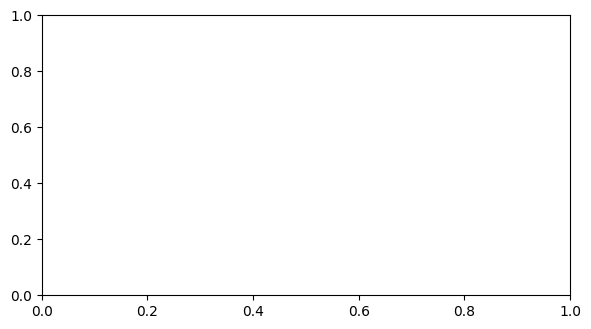

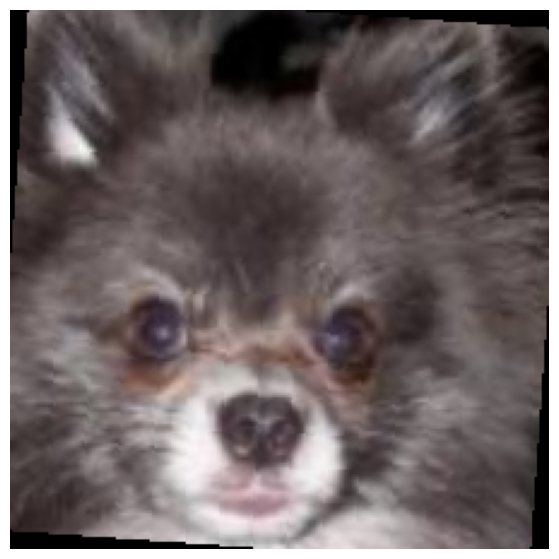

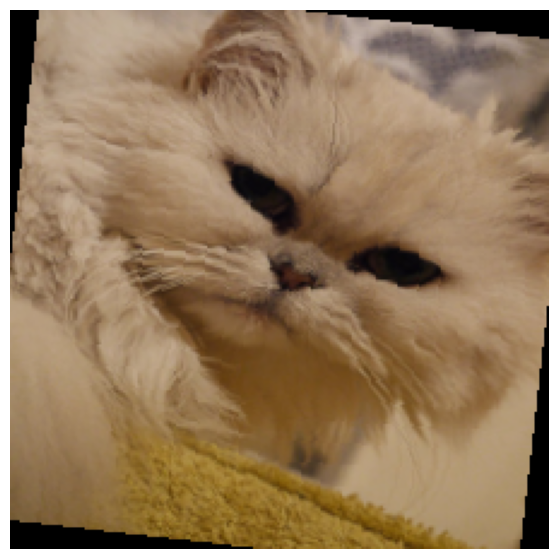

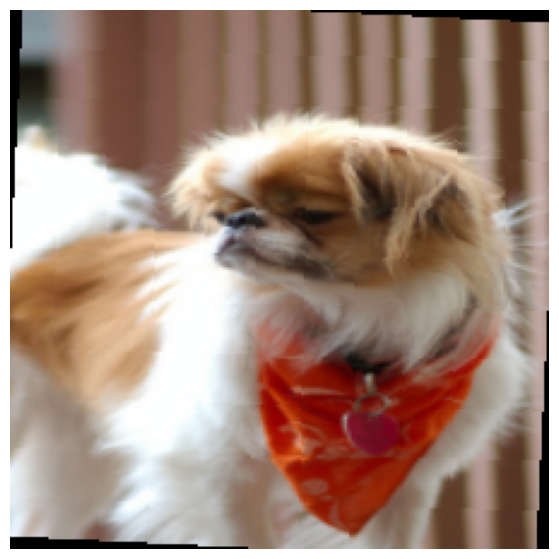

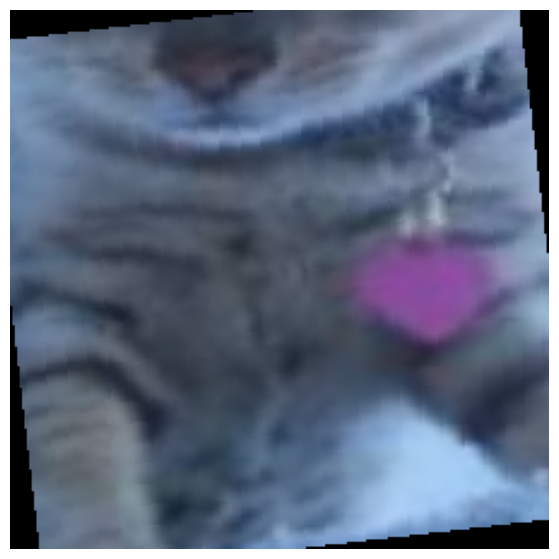

<Figure size 640x480 with 0 Axes>

In [12]:
# Функция для отображения изображений
def imshow(img):
    # Денормализация изображения
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(15, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Получим несколько тренировочных изображений
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Показываем изображения и их метки
fig = plt.figure(figsize=(15, 8))
for i in range(4):
    ax = fig.add_subplot(2, 2, i+1)
    imshow(images[i])
    ax.set_title(f'Класс: {classes[labels[i]]}')
    ax.axis('off')
plt.tight_layout()


In [41]:
# Загружаем предобученную модель ResNet-50
model_ft = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

In [51]:
def evaluate_model(model, dataloader):
    model.eval()
    running_corrects = 0
    
    # Отключаем вычисление градиентов
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Получаем предсказания
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            # Считаем верные предсказания
            running_corrects += torch.sum(preds == labels.data)
    
    # Вычисляем точность
    acc = running_corrects / len(dataloader.dataset)
    return acc.item()

In [43]:
# Функция для визуализации предсказаний модели
def visualize_model_predictions(model, dataloader, class_names, title, num_images=6):
    model.eval()
    
    # Получаем батч изображений
    images_so_far = 0
    fig = plt.figure(figsize=(18, 8))
    plt.suptitle(title, fontsize=16)
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, num_images//2, images_so_far)
                ax.axis('off')
                
                # Проверяем, правильно ли классифицировано изображение
                is_correct = preds[j] == labels[j]
                title_color = "green" if is_correct else "red"
                
                ax.set_title(f'Предсказано: {class_names[preds[j]]}\nПравильно: {class_names[labels[j]]}',
                             color=title_color)
                
                # Преобразуем изображение для показа
                img = inputs.cpu().data[j].permute(1, 2, 0).numpy()
                # Денормализация
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                ax.imshow(img)
                
                if images_so_far == num_images:
                    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Оставляем место для общего заголовка
                    plt.show()
                    return

### Метод 1: Замена только головы модели

In [45]:
model_method1 = copy.deepcopy(model_ft)

# Замораживаем все слои модели
for param in model_method1.parameters():
    param.requires_grad = False
    
# Заменяем последний полносвязный слой (голову) на новый для наших 37 классов
num_ftrs = model_method1.fc.in_features
model_method1.fc = nn.Linear(num_ftrs, len(classes))

model_method1 = model_method1.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_method1 = optim.AdamW(model_method1.fc.parameters(), lr=0.001)
scheduler_method1 = optim.lr_scheduler.StepLR(optimizer_method1, step_size=7, gamma=0.1)


params_to_update = [p for p in model_method1.parameters() if p.requires_grad]
print(f"Количество обучаемых параметров (Метод 1): {len(params_to_update)}")

Количество обучаемых параметров (Метод 1): 2


In [46]:
params_to_update = [p for p in model_method1.parameters() if p.requires_grad]
params_to_update[0].shape, params_to_update[1].shape

(torch.Size([37, 2048]), torch.Size([37]))

In [47]:
# Настройка для обучения
dataloaders = {'train': trainloader, 'val': valloader}
dataset_sizes = {'train': len(trainset), 'val': len(valset)}

# Обучаем модель с замороженными слоями (Метод 1)
model_method1, history_method1 = train_model(
    model_method1, criterion, optimizer_method1, scheduler_method1,
    dataloaders, dataset_sizes, num_epochs=5)

Эпоха 1/5
----------
train Loss: 2.4912 Acc: 0.4952
val Loss: 1.6112 Acc: 0.7432

Эпоха 2/5
----------
train Loss: 1.3227 Acc: 0.7534
val Loss: 1.0491 Acc: 0.8071

Эпоха 3/5
----------
train Loss: 0.9542 Acc: 0.8020
val Loss: 0.8523 Acc: 0.8247

Эпоха 4/5
----------
train Loss: 0.7574 Acc: 0.8251
val Loss: 0.7543 Acc: 0.8179

Эпоха 5/5
----------
train Loss: 0.6748 Acc: 0.8414
val Loss: 0.7096 Acc: 0.8220

Обучение завершено за 3m 36s
Лучшая точность на валидации: 0.8247


Точность Метода 1 (только замена головы) на тестовой выборке: 0.8735


TypeError: can't convert mps:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

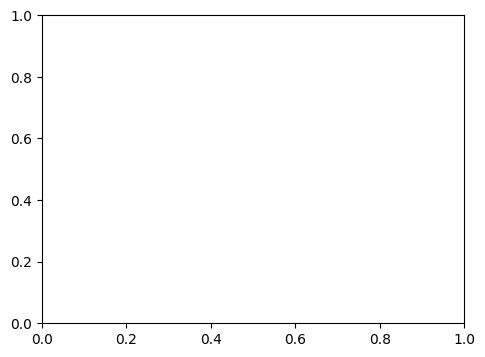

In [52]:
# Оцениваем модель с замороженными слоями (Метод 1) на тестовой выборке
acc_method1 = evaluate_model(model_method1, testloader)
print(f"Точность Метода 1 (только замена головы) на тестовой выборке: {acc_method1:.4f}")

In [59]:
history_method1['val_acc'] = [a.cpu() for a in history_method1['val_acc']]

In [60]:
history_method1

{'train_loss': [2.491233192060305,
  1.322654752627663,
  0.9542386305073033,
  0.7574054819086323,
  0.6748077399704767],
 'train_acc': [tensor(0.4952),
  tensor(0.7534),
  tensor(0.8020),
  tensor(0.8251),
  tensor(0.8414)],
 'val_loss': [1.611229139825572,
  1.0490924508675286,
  0.8522954194442086,
  0.7542818525563115,
  0.7096466007439987],
 'val_acc': [tensor(0.7432),
  tensor(0.8071),
  tensor(0.8247),
  tensor(0.8179),
  tensor(0.8220)]}

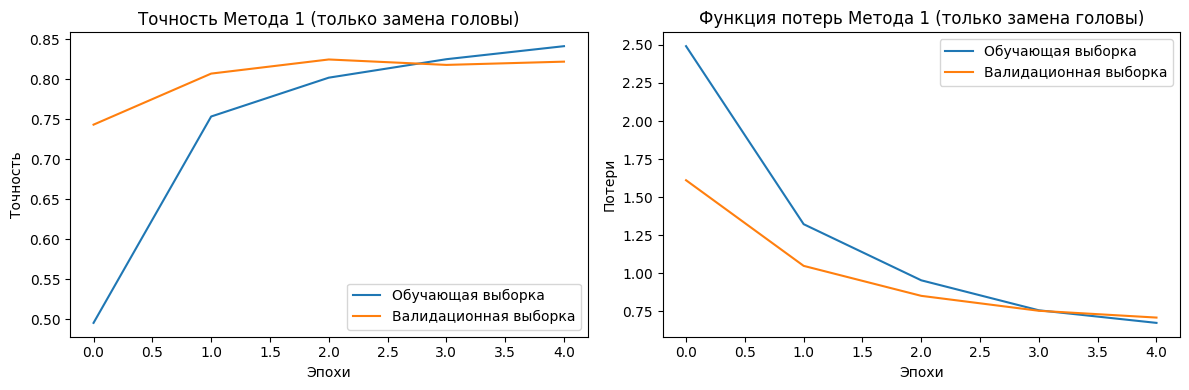

In [62]:
# Визуализируем кривые обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_method1['train_acc'], label='Обучающая выборка')
plt.plot(history_method1['val_acc'], label='Валидационная выборка')
plt.title('Точность Метода 1 (только замена головы)')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_method1['train_loss'], label='Обучающая выборка')
plt.plot(history_method1['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь Метода 1 (только замена головы)')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Визуализируем предсказания модели Метода 1
visualize_model_predictions(model_method1, testloader, classes, 
                           "Предсказания модели с замороженными слоями (Метод 1)")

In [64]:
model_base = models.resnet50()

# Замораживаем все слои модели
for param in model_base.parameters():
    param.requires_grad = False
    
# Заменяем последний полносвязный слой (голову) на новый для наших 37 классов
num_ftrs = model_base.fc.in_features
model_base.fc = nn.Linear(num_ftrs, len(classes))

model_base = model_base.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_method1 = optim.AdamW(model_base.fc.parameters(), lr=0.001)
scheduler_method1 = optim.lr_scheduler.StepLR(optimizer_method1, step_size=7, gamma=0.1)


params_to_update = [p for p in model_base.parameters() if p.requires_grad]
print(f"Количество обучаемых параметров (Метод 1): {len(params_to_update)}")

Количество обучаемых параметров (Метод 1): 2


In [65]:
# Настройка для обучения
dataloaders = {'train': trainloader, 'val': valloader}
dataset_sizes = {'train': len(trainset), 'val': len(valset)}

# Обучаем модель с замороженными слоями (Метод 1)
model_method1, history_method1 = train_model(
    model_base, criterion, optimizer_method1, scheduler_method1,
    dataloaders, dataset_sizes, num_epochs=5)

Эпоха 1/5
----------
train Loss: 4.2015 Acc: 0.0323
val Loss: 3.8707 Acc: 0.0285

Эпоха 2/5
----------
train Loss: 3.9913 Acc: 0.0262
val Loss: 4.0631 Acc: 0.0380

Эпоха 3/5
----------
train Loss: 3.9973 Acc: 0.0329
val Loss: 4.0556 Acc: 0.0408

Эпоха 4/5
----------
train Loss: 4.1038 Acc: 0.0241
val Loss: 4.1627 Acc: 0.0367

Эпоха 5/5
----------
train Loss: 4.0775 Acc: 0.0323
val Loss: 4.0996 Acc: 0.0367

Обучение завершено за 3m 33s
Лучшая точность на валидации: 0.0408


In [66]:
history_method1['train_acc'] = [a.cpu() for a in history_method1['train_acc']]
history_method1['val_acc'] = [a.cpu() for a in history_method1['val_acc']]

Точность Метода 1 (только замена головы) на тестовой выборке: 0.0398


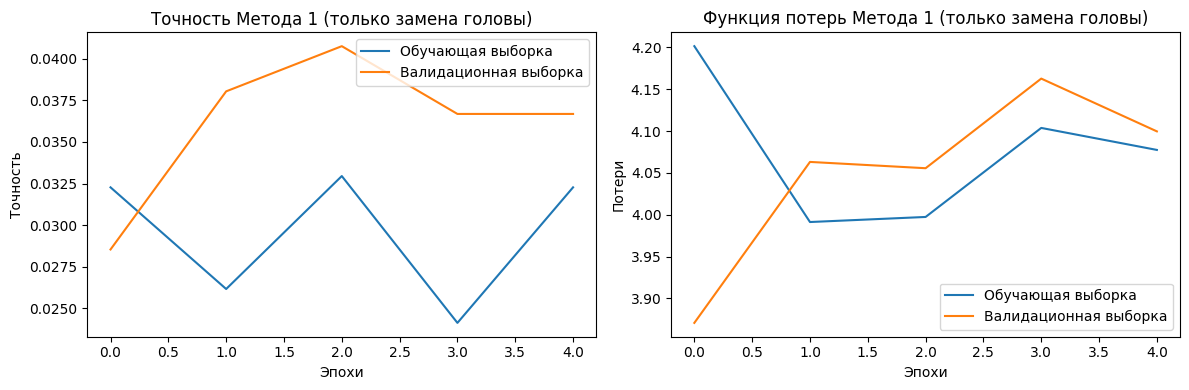

In [67]:
# Оцениваем модель с замороженными слоями (Метод 1) на тестовой выборке
acc_method1 = evaluate_model(model_base, testloader)
print(f"Точность Метода 1 (только замена головы) на тестовой выборке: {acc_method1:.4f}")

# Визуализируем кривые обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_method1['train_acc'], label='Обучающая выборка')
plt.plot(history_method1['val_acc'], label='Валидационная выборка')
plt.title('Точность Метода 1 (только замена головы)')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_method1['train_loss'], label='Обучающая выборка')
plt.plot(history_method1['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь Метода 1 (только замена головы)')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Визуализируем предсказания модели Метода 1
visualize_model_predictions(model_base, testloader, classes, 
                           "Предсказания модели с замороженными слоями (Метод 1)")


### Метод 2: Замена головы и частичная разморозка слоев

In [ ]:
# Копируем модель для второго метода
model_method2 = copy.deepcopy(model_ft)

# Сначала замораживаем все слои
for param in model_method2.parameters():
    param.requires_grad = False
    
# Размораживаем последние несколько слоев
# Для ResNet50 размораживаем layer4 (последний блок)
for param in model_method2.layer4.parameters():
    param.requires_grad = True
    
# Заменяем классификатор
num_ftrs = model_method2.fc.in_features
model_method2.fc = nn.Linear(num_ftrs, len(classes))

# Перемещаем модель на устройство
model_method2 = model_method2.to(device)

# Определяем функцию потерь
criterion = nn.CrossEntropyLoss()

# Выводим количество обучаемых параметров
params_to_update = [p for p in model_method2.parameters() if p.requires_grad]
print(f"Количество обучаемых параметров (Метод 2): {len(params_to_update)}")

# Используем разные скорости обучения для разных частей модели
optimizer_method2 = optim.SGD([
    {'params': model_method2.layer4.parameters(), 'lr': 0.0001},
    {'params': model_method2.fc.parameters(), 'lr': 0.001}
], momentum=0.9)

scheduler_method2 = optim.lr_scheduler.StepLR(optimizer_method2, step_size=7, gamma=0.1)


In [ ]:
# Обучаем модель с частично размороженными слоями (Метод 2)
model_method2, history_method2 = train_model(
    model_method2, criterion, optimizer_method2, scheduler_method2,
    dataloaders, dataset_sizes, num_epochs=5)

In [ ]:
# Оцениваем модель с частично размороженными слоями (Метод 2) на тестовой выборке
acc_method2 = evaluate_model(model_method2, testloader)
print(f"Точность Метода 2 (частичная разморозка) на тестовой выборке: {acc_method2:.4f}")

# Визуализируем кривые обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_method2['train_acc'], label='Обучающая выборка')
plt.plot(history_method2['val_acc'], label='Валидационная выборка')
plt.title('Точность Метода 2 (частичная разморозка)')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_method2['train_loss'], label='Обучающая выборка')
plt.plot(history_method2['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь Метода 2 (частичная разморозка)')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Визуализируем предсказания модели Метода 2
visualize_model_predictions(model_method2, testloader, classes, 
                           "Предсказания модели с частично размороженными слоями (Метод 2)")

### Сравним модели

In [ ]:
# Вычисляем улучшение
improvement = (acc_method2 - acc_method1) * 100
print(f"Точность на тестовой выборке (Метод 1, только замена головы): {acc_method1:.4f}")
print(f"Точность на тестовой выборке (Метод 2, частичная разморозка): {acc_method2:.4f}")
print(f"Улучшение точности при частичной разморозке: {improvement:.2f}%")

# Построение сравнительных графиков точности и потерь
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_method1['train_acc'], label='Метод 1 - Обучающая')
plt.plot(history_method1['val_acc'], label='Метод 1 - Валидационная')
plt.plot(history_method2['train_acc'], label='Метод 2 - Обучающая')
plt.plot(history_method2['val_acc'], label='Метод 2 - Валидационная')
plt.title('Сравнение точности методов')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_method1['train_loss'], label='Метод 1 - Обучающая')
plt.plot(history_method1['val_loss'], label='Метод 1 - Валидационная')
plt.plot(history_method2['train_loss'], label='Метод 2 - Обучающая')
plt.plot(history_method2['val_loss'], label='Метод 2 - Валидационная')
plt.title('Сравнение функции потерь методов')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Функция для анализа точности по классам
def analyze_class_accuracy(model, dataloader, class_names):
    model.eval()
    class_correct = list(0. for i in range(len(class_names)))
    class_total = list(0. for i in range(len(class_names)))
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            c = (preds == labels).squeeze()
            
            for i in range(len(inputs)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # Вычисляем точность по классам и сортируем
    accuracy_by_class = []
    for i in range(len(class_names)):
        if class_total[i] > 0:
            accuracy = 100 * class_correct[i] / class_total[i]
            accuracy_by_class.append((class_names[i], accuracy))
    
    # Сортируем по точности (возрастание)
    accuracy_by_class.sort(key=lambda x: x[1])
    
    return accuracy_by_class

# Получаем точность по классам для обоих методов
accuracy_method1 = analyze_class_accuracy(model_method1, testloader, classes)
accuracy_method2 = analyze_class_accuracy(model_method2, testloader, classes)

# Визуализируем результаты для наиболее сложных и наиболее легких классов
plt.figure(figsize=(14, 8))

# 5 самых сложных классов
plt.subplot(1, 2, 1)
class_names = [x[0] for x in accuracy_method1[:5]]
accuracy1 = [x[1] for x in accuracy_method1[:5]]
# Находим соответствующие точности для метода 2
accuracy2 = []
for class_name in class_names:
    for c, acc in accuracy_method2:
        if c == class_name:
            accuracy2.append(acc)
            break

x = np.arange(len(class_names))
width = 0.35
plt.bar(x - width/2, accuracy1, width, label='Метод 1')
plt.bar(x + width/2, accuracy2, width, label='Метод 2')
plt.axhline(y=50, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Класс')
plt.ylabel('Точность (%)')
plt.title('5 самых сложных пород')
plt.xticks(x, class_names, rotation=45, ha="right")
plt.legend()

# 5 самых легких классов
plt.subplot(1, 2, 2)
class_names = [x[0] for x in accuracy_method1[-5:]]
accuracy1 = [x[1] for x in accuracy_method1[-5:]]
# Находим соответствующие точности для метода 2
accuracy2 = []
for class_name in class_names:
    for c, acc in accuracy_method2:
        if c == class_name:
            accuracy2.append(acc)
            break

x = np.arange(len(class_names))
plt.bar(x - width/2, accuracy1, width, label='Метод 1')
plt.bar(x + width/2, accuracy2, width, label='Метод 2')
plt.axhline(y=90, color='g', linestyle='-', alpha=0.3)
plt.xlabel('Класс')
plt.ylabel('Точность (%)')
plt.title('5 самых легких пород')
plt.xticks(x, class_names, rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()
